# LLM Experiment-7

In [9]:
!pip install -q transformers pillow torch torchvision

In [3]:
import torch
from PIL import Image
import requests
from transformers import BlipProcessor, BlipForConditionalGeneration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

print("Model loaded successfully!")

Using device: cuda


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Model loaded successfully!


In [10]:
def generate_caption(image_input, text_prompt=None):
    if isinstance(image_input, str):
        raw_image = Image.open(requests.get(image_input, stream=True).raw).convert('RGB')
    else:
        raw_image = image_input.convert('RGB')

    if text_prompt:
        inputs = processor(raw_image, text_prompt, return_tensors="pt").to(device)
    else:
        inputs = processor(raw_image, return_tensors="pt").to(device)

    out = model.generate(**inputs, max_new_tokens=50)

    caption = processor.decode(out[0], skip_special_tokens=True)

    return raw_image, caption

In [28]:
img_urls = [
    "https://img.freepik.com/free-photo/lavender-field-sunset-near-valensole_268835-3910.jpg?semt=ais_incoming&w=740&q=80",
    "https://img.freepik.com/free-photo/closeup-shot-beautiful-butterfly-with-interesting-textures-orange-petaled-flower_181624-7640.jpg?semt=ais_incoming&w=740&q=80",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQVBmvQ0vWIbzrOhkQyUhU-iQ2M2NYbm9lnzg&s",
    "https://searchengineland.com/wp-content/seloads/2014/08/photos-images-pictures-ss-1920.jpg",
    "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"
]

Saving aston-martin-vanquish.jpg to aston-martin-vanquish (1).jpg
Enter start prompt: An image of 


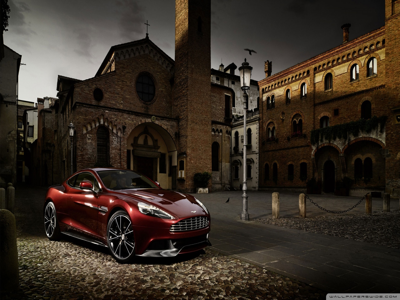

Generated Caption: an image of a red sports car parked in a street


In [29]:
from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
    user_img = Image.open(filename)
    prompt = input("Enter start prompt: ")
    img, cap = generate_caption(user_img, prompt)
    display(img.resize((400, 300)))
    print(f"Generated Caption: {cap}")

Processing image: https://img.freepik.com/free-photo/lavender-field-sunset-near-valensole_268835-3910.jpg?semt=ais_incoming&w=740&q=80


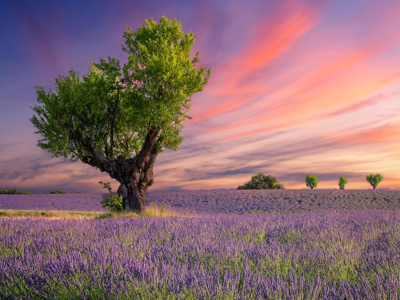

Generated Caption: lavender field at sunset

Processing image: https://img.freepik.com/free-photo/closeup-shot-beautiful-butterfly-with-interesting-textures-orange-petaled-flower_181624-7640.jpg?semt=ais_incoming&w=740&q=80


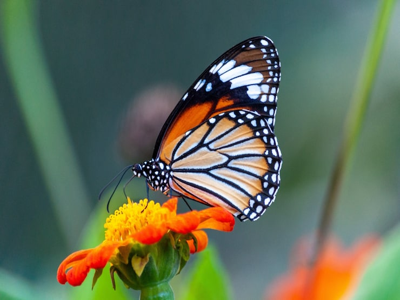

Generated Caption: a butterfly on a flower

Processing image: https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQVBmvQ0vWIbzrOhkQyUhU-iQ2M2NYbm9lnzg&s


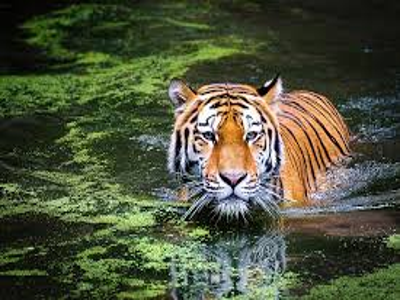

Generated Caption: a tiger swimming in a pond

Processing image: https://searchengineland.com/wp-content/seloads/2014/08/photos-images-pictures-ss-1920.jpg


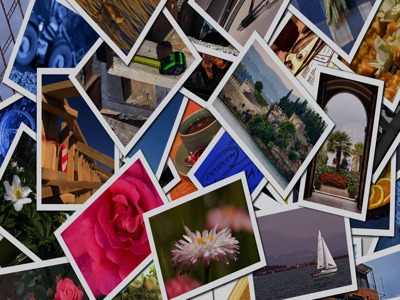

Generated Caption: a col of pictures of flowers and buildings

Processing image: https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg


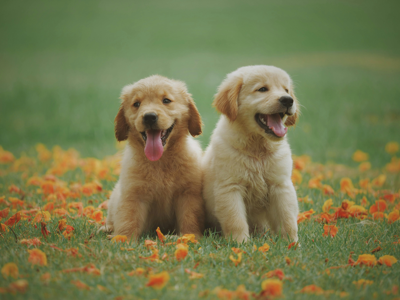

Generated Caption: two pup sitting in a field of flowers



In [30]:
from IPython.display import display

for url in img_urls:
    print(f"Processing image: {url}")
    text_prompt = ""
    img, cap = generate_caption(url, text_prompt)
    display(img.resize((400, 300)))
    print(f"Generated Caption: {cap}\n")